In [1]:
import pandas as pd
import numpy as np


In [2]:
data=pd.read_csv('Customer-Churn.csv')

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [10]:
print("Null count in TotalCharges:", data['TotalCharges'].isnull().sum())

Null count in TotalCharges: 11


In [11]:
# حذف الـ 11 صف المفقودين
data.dropna(inplace=True)

# التأكد من مسحهم وإسقاط عمود customerID (لأنه مجرد رقم تعريفي مش هيسهم في التنبؤ)
data.drop(columns=['customerID'], inplace=True)

In [12]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Preprocessing

In [13]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [14]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

In [15]:
data.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)

In [16]:
cols_binary = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

In [17]:
data['gender'] = data['gender'].map({'Female': 1, 'Male': 0})

for col in cols_binary:
    if col != 'gender':
        data[col] = data[col].map({'Yes': 1, 'No': 0})

In [18]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [19]:
from sklearn.preprocessing import LabelEncoder ,OneHotEncoder

In [20]:
cols_Multi_value = ['InternetService', 'Contract', 'PaymentMethod']

data = pd.get_dummies(data, columns=cols_Multi_value, drop_first=True)

In [21]:
data.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
7038,0,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,0,False,False,True,False,False,False,True
7039,1,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,True,False,True,False,True,False,False
7040,1,0,1,1,11,0,0,1,0,0,...,29.60,346.45,0,False,False,False,False,False,True,False
7041,0,1,1,0,4,1,1,0,0,0,...,74.40,306.60,1,True,False,False,False,False,False,True
7042,0,0,0,0,66,1,0,1,0,1,...,105.65,6844.50,0,True,False,False,True,False,False,False


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [23]:
X = data.drop(columns=['Churn'])
y = data['Churn']

In [24]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

In [28]:
print(f'x_train shape : {X_train.shape}')
print(f'x_test shape : {X_test.shape}')



x_train shape : (4925, 23)
x_test shape : (1055, 23)


In [29]:
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [30]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [31]:
import tensorflow as tf

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [35]:
from tensorflow.keras.layers import Input

In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),  
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [37]:
# 2. تجميع الموديل
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,                  
    batch_size=32,             
    validation_data=(X_val, y_val), 
    verbose=1
)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7139 - loss: 0.5548 - val_accuracy: 0.7785 - val_loss: 0.4630
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7978 - loss: 0.4300 - val_accuracy: 0.7947 - val_loss: 0.4342
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7994 - loss: 0.4187 - val_accuracy: 0.7947 - val_loss: 0.4357
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8020 - loss: 0.4149 - val_accuracy: 0.7966 - val_loss: 0.4314
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8067 - loss: 0.4126 - val_accuracy: 0.7937 - val_loss: 0.4277
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8053 - loss: 0.4102 - val_accuracy: 0.7975 - val_loss: 0.4237
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8061 - loss: 0.4091 - val_accuracy: 0.7985 - val_loss: 0.4255
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8083 - loss: 0.4069 - val_accuracy: 0.

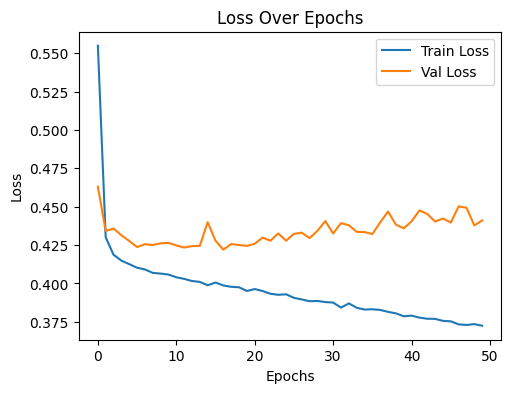

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

# رسم Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

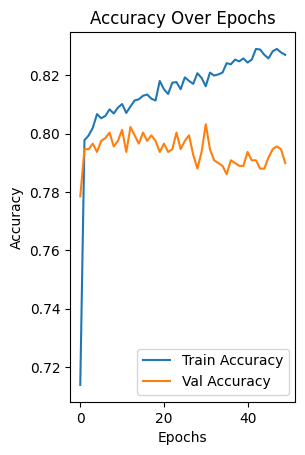

In [41]:
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [42]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
model_reg = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(32, activation='relu'),
    Dropout(0.3),  
    
    Dense(16, activation='relu'),
    Dropout(0.2), 
    
    Dense(1, activation='sigmoid')
])

In [44]:
model_reg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',     
    patience=10,            
    restore_best_weights=True 
)

In [46]:
history_reg = model_reg.fit(
    X_train, y_train,
    epochs=100,           
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop], # إضافة الـ callback
    verbose=1
)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7025 - loss: 0.5678 - val_accuracy: 0.7823 - val_loss: 0.4542
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7838 - loss: 0.4632 - val_accuracy: 0.7814 - val_loss: 0.4334
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7880 - loss: 0.4499 - val_accuracy: 0.7833 - val_loss: 0.4297
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7927 - loss: 0.4410 - val_accuracy: 0.7880 - val_loss: 0.4275
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7868 - loss: 0.4413 - val_accuracy: 0.7909 - val_loss: 0.4285
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7907 - loss: 0.4324 - val_accuracy: 0.7937 - val_loss: 0.4250
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7917 - loss: 0.4333 - val_accuracy: 0.7918 - val_loss: 0.4244
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8012 - loss: 0.4277 - val_accu

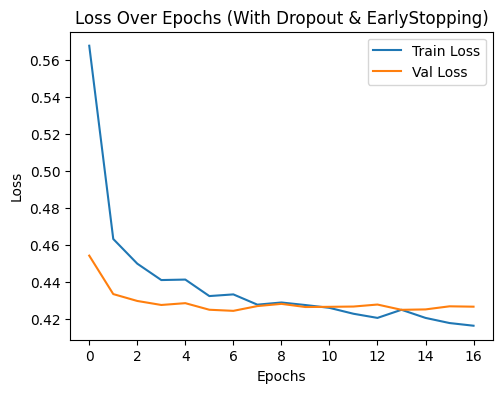

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs (With Dropout & EarlyStopping)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()



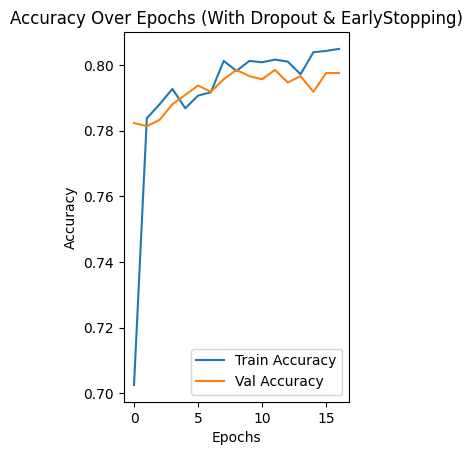

In [48]:
# 2. رسم الـ Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_reg.history['accuracy'], label='Train Accuracy')
plt.plot(history_reg.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs (With Dropout & EarlyStopping)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [49]:
test_loss, test_acc = model_reg.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_probs = model_reg.predict(X_test)
y_pred = (y_pred_probs >= 0.5).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7877
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       775
           1       0.61      0.55      0.58       280

    accuracy                           0.79      1055
   macro avg       0.73      0.71      0.72      1055
weighted avg       0.78      0.79      0.78      1055



In [50]:
train_loss, train_acc = model_reg.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc     = model_reg.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc   = model_reg.evaluate(X_test, y_test, verbose=0)

# 2. طباعة النتائج جنب بعض للمقارنة المباشرة
print(f"🔹 Train Accuracy: {train_acc*100:.2f}% | Train Loss: {train_loss:.4f}")
print(f"🔹 Val Accuracy:   {val_acc*100:.2f}% | Val Loss:   {val_loss:.4f}")
print(f"🔹 Test Accuracy:  {test_acc*100:.2f}% | Test Loss:  {test_loss:.4f}")

🔹 Train Accuracy: 80.73% | Train Loss: 0.4108
🔹 Val Accuracy:   79.18% | Val Loss:   0.4244
🔹 Test Accuracy:  78.77% | Test Loss:  0.4369
